In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

np.random.seed(42)
X, y = make_moons(n_samples=3000, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_estimator = DecisionTreeClassifier(max_depth=5, random_state=42)
bagging_model = BaggingClassifier(estimator=base_estimator, n_estimators=50, max_samples=0.8, random_state=42)

bagging_model.fit(X_train, y_train)

y_pred_train = bagging_model.predict(X_train)
y_pred_test = bagging_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.91
Testing Accuracy: 0.90


In [3]:
X

array([[-0.20163578, -0.2635946 ],
       [-1.0830892 ,  0.51218891],
       [ 0.6049659 , -0.22974369],
       ...,
       [-0.9707312 ,  0.60393989],
       [-0.54502574,  0.31378309],
       [ 0.08480783,  1.16907575]], shape=(3000, 2))

In [4]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(3000,))

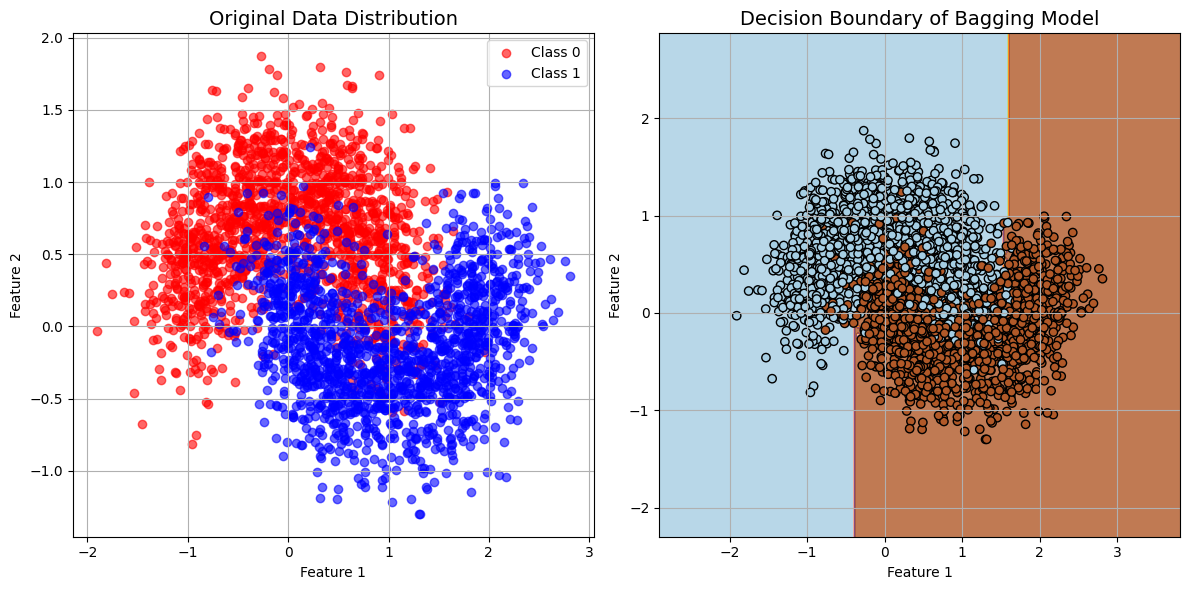

In [5]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Data Distribution", fontsize=14)
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
plt.legend()
plt.grid(True)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])  ## 按列拼接
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)  # 决策边界
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title(title, fontsize=14)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)

plt.subplot(1, 2, 2)
plot_decision_boundary(bagging_model, X, y, "Decision Boundary of Bagging Model")

plt.tight_layout()
plt.show()

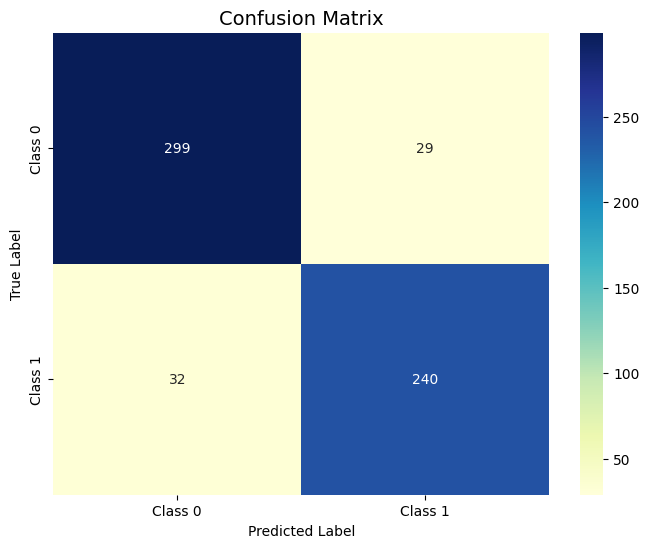

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()